# Exploratory Data Analysis

This notebook explores the cleaned NCRP recidivism dataset created by `01_data_preprocessing.ipynb`.

The goal is to understand the analysis sample before modeling: state coverage, release-year trends, recidivism patterns, individual composition, and descriptive policy variation. The notebook also flags data-quality issues that matter for the regression notebooks, especially right-censoring near the end of the panel and missing policy matches.

Regression specifications and causal estimates are handled in the `regression/` notebooks.

**Input:** `data/processed/clean_recidivism.csv`  
**Output:** descriptive tables and figures only; this notebook does not write analysis data.

## 1. Imports and Settings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.3f}".format)

DATA_PATH = Path("../data/processed/clean_recidivism.csv")

## 2. Load Cleaned Data

Load the processed file generated by the preprocessing notebook. If this fails, run `01_data_preprocessing.ipynb` first.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DATA_PATH}. Run data_processing/01_data_preprocessing.ipynb first."
    )

category_cols = ["STATE_NAME", "policy_tier"]
dtype_map = {
    "ABT_INMATE_ID": "string",
    "SEX": "Int8",
    "ADMTYPE": "Int8",
    "OFFGENERAL": "Int8",
    "ADMITYR": "Int16",
    "RELEASEYR": "Int16",
    "SENTLGTH": "float32",
    "OFFDETAIL": "float32",
    "RACE": "float32",
    "AGEADMIT": "float32",
    "AGERELEASE": "float32",
    "TIMESRVD": "Int16",
    "RELTYPE": "float32",
    "STATE": "Int16",
    "within_2_yrs": "Int8",
    "tot_arrest_counts": "Int16",
    "ABE_Literacy": "float32",
    "Secondary": "float32",
    "Vocational": "float32",
    "College": "float32",
    "Automatic_Enrollment": "float32",
    "School_District": "float32",
    "Sentence_Reduction": "float32",
    "Total_Score": "float32",
}

df = pd.read_csv(DATA_PATH, dtype=dtype_map)
for col in category_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Memory:  {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
df.head()

Rows:    11,547,985
Columns: 26
Memory:  1.72 GB


,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,ADMITYR,RELEASEYR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE,STATE_NAME,within_2_yrs,tot_arrest_counts,ABE_Literacy,Secondary,Vocational,College,Automatic_Enrollment,School_District,Sentence_Reduction,Total_Score,policy_tier
0,A012021000000000001,1,1,2,2011,2011,0.000,7.000,1.000,2.000,2.000,0,1.000,1,Alabama,0,1,0.000,0.000,0.000,0.500,0.000,0.000,1.000,1.500,Low
1,A012021000000000002,1,1,2,2016,2016,2.000,8.000,1.000,2.000,2.000,0,NaN,1,Alabama,1,2,0.000,0.000,0.000,0.500,0.000,0.000,1.000,1.500,Low
2,A012021000000000002,1,3,2,2017,2018,2.000,8.000,1.000,2.000,2.000,1,2.000,1,Alabama,0,2,0.000,0.000,0.000,0.500,0.000,0.000,1.000,1.500,Low
3,A012021000000000003,1,1,3,2011,2012,2.000,12.000,NaN,3.000,3.000,0,2.000,1,Alabama,0,1,0.000,0.000,0.000,0.500,0.000,0.000,1.000,1.500,Low
4,A012021000000000004,1,9,2,2003,2007,4.000,7.000,1.000,1.000,2.000,2,3.000,1,Alabama,0,2,0.000,0.000,0.000,0.500,0.000,0.000,1.000,1.500,Low


## 3. Data Contract

Check that the cleaned file contains the fields needed by the downstream regression notebooks. Missing values in policy columns are especially important because those records can be dropped from policy regressions.

In [3]:
required_cols = [
    "ABT_INMATE_ID",
    "STATE_NAME",
    "ADMITYR",
    "RELEASEYR",
    "within_2_yrs",
    "SEX",
    "AGEADMIT",
    "SENTLGTH",
    "OFFGENERAL",
    "tot_arrest_counts",
    "ABE_Literacy",
    "Secondary",
    "Vocational",
    "College",
    "Automatic_Enrollment",
    "School_District",
    "Sentence_Reduction",
    "Total_Score",
    "policy_tier",
]

missing_cols = [col for col in required_cols if col not in df.columns]
print(f"Missing required columns: {missing_cols}")

summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_rate": df.isna().mean(),
        "unique": df.nunique(dropna=True),
    }
)
summary.loc[[col for col in required_cols if col in summary.index]]

policy_missing_states = sorted(
    df.loc[df["Total_Score"].isna(), "STATE_NAME"].dropna().astype(str).unique()
)
print(f"States with missing policy data: {policy_missing_states}")

Missing required columns: []
States with missing policy data: ['District of Columbia']


## 4. Sample Coverage

Describe release-year and state coverage. The cleaned file contains historical records, while the main policy analyses focus on the modern window around the 2016 Pell expansion. The final release years should be interpreted carefully because two-year recidivism requires future admission records.

In [4]:
person_records = df.drop_duplicates("ABT_INMATE_ID")["tot_arrest_counts"]
analysis_df = df[(df["RELEASEYR"] >= 2005) & (df["RELEASEYR"] <= 2017)]

coverage = pd.Series(
    {
        "rows": len(df),
        "unique_people": df["ABT_INMATE_ID"].nunique(),
        "states": df["STATE_NAME"].nunique(),
        "first_release_year": df["RELEASEYR"].min(),
        "last_release_year": df["RELEASEYR"].max(),
        "overall_recidivism_rate": df["within_2_yrs"].mean(),
        "records_per_person": len(df) / df["ABT_INMATE_ID"].nunique(),
        "analysis_window_rows_2005_2017": len(analysis_df),
        "analysis_window_recidivism_2005_2017": analysis_df["within_2_yrs"].mean(),
    }
)
coverage

rows                                   11547985.000
unique_people                           6143985.000
states                                       34.000
first_release_year                         1971.000
last_release_year                          2018.000
overall_recidivism_rate                       0.263
records_per_person                            1.880
analysis_window_rows_2005_2017          7062118.000
analysis_window_recidivism_2005_2017          0.245
dtype: float64

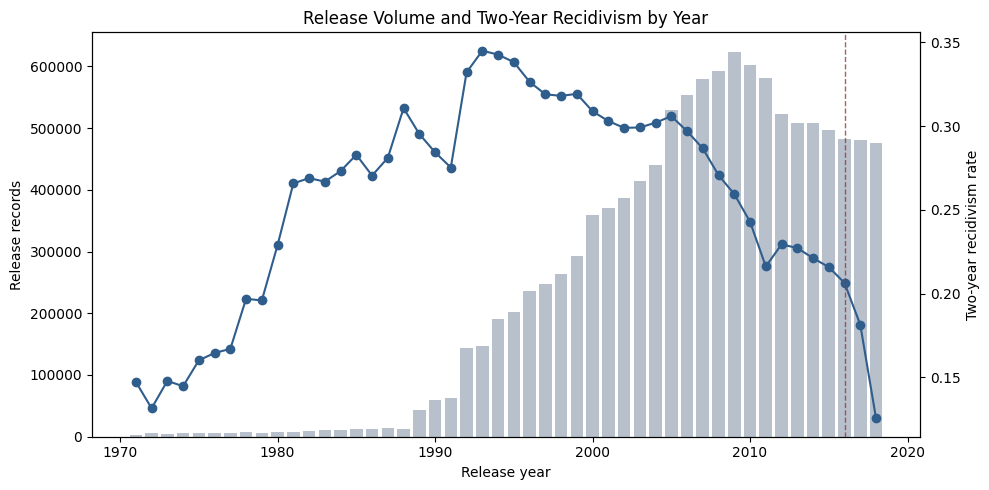

,RELEASEYR,releases,recid_rate
34,2005,528599,0.306
35,2006,553594,0.297
36,2007,579847,0.287
37,2008,592650,0.271
38,2009,623865,0.259
39,2010,602211,0.243
40,2011,580718,0.216
41,2012,523317,0.229
42,2013,508963,0.227
43,2014,508319,0.221


In [5]:
yearly = (
    df.groupby("RELEASEYR", observed=True)
    .agg(releases=("within_2_yrs", "size"), recid_rate=("within_2_yrs", "mean"))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(yearly["RELEASEYR"], yearly["releases"], color="#b8c0cc", label="Releases")
ax1.set_ylabel("Release records")
ax1.set_xlabel("Release year")

ax2 = ax1.twinx()
ax2.plot(yearly["RELEASEYR"], yearly["recid_rate"], color="#2f5d8c", marker="o")
ax2.set_ylabel("Two-year recidivism rate")
ax2.axvline(2016, color="#8a3d3d", linestyle="--", linewidth=1, alpha=0.8)

ax1.set_title("Release Volume and Two-Year Recidivism by Year")
fig.tight_layout()
plt.show()

yearly[yearly["RELEASEYR"] >= 2005]

## 5. State-Level Variation

State differences are central to the project because policy exposure is assigned at the state level. This section summarizes release volume and recidivism by state without estimating policy effects.

In [6]:
state_summary = (
    df.groupby("STATE_NAME", observed=True)
    .agg(
        releases=("within_2_yrs", "size"),
        people=("ABT_INMATE_ID", "nunique"),
        first_year=("RELEASEYR", "min"),
        last_year=("RELEASEYR", "max"),
        recid_rate=("within_2_yrs", "mean"),
        total_score=("Total_Score", "first"),
        sentence_reduction=("Sentence_Reduction", "first"),
    )
    .sort_values("releases", ascending=False)
)

state_summary.head(15)

,releases,people,first_year,last_year,recid_rate,total_score,sentence_reduction
STATE_NAME,,,,,,,
California,2540517,991397,1992,2018,0.339,6.250,1.000
Texas,1115950,688626,2005,2018,0.246,4.500,1.000
Illinois,795049,356622,1989,2018,0.302,5.250,1.000
Florida,701088,449344,1996,2018,0.179,2.000,1.000
Georgia,677451,380705,1971,2018,0.222,2.000,1.000
New York,655566,337894,1994,2018,0.278,5.000,1.000
North Carolina,462137,264469,1999,2018,0.224,2.750,1.000
Pennsylvania,435423,210656,1990,2018,0.257,3.000,0.000
Missouri,380002,178612,1998,2018,0.318,1.000,0.000


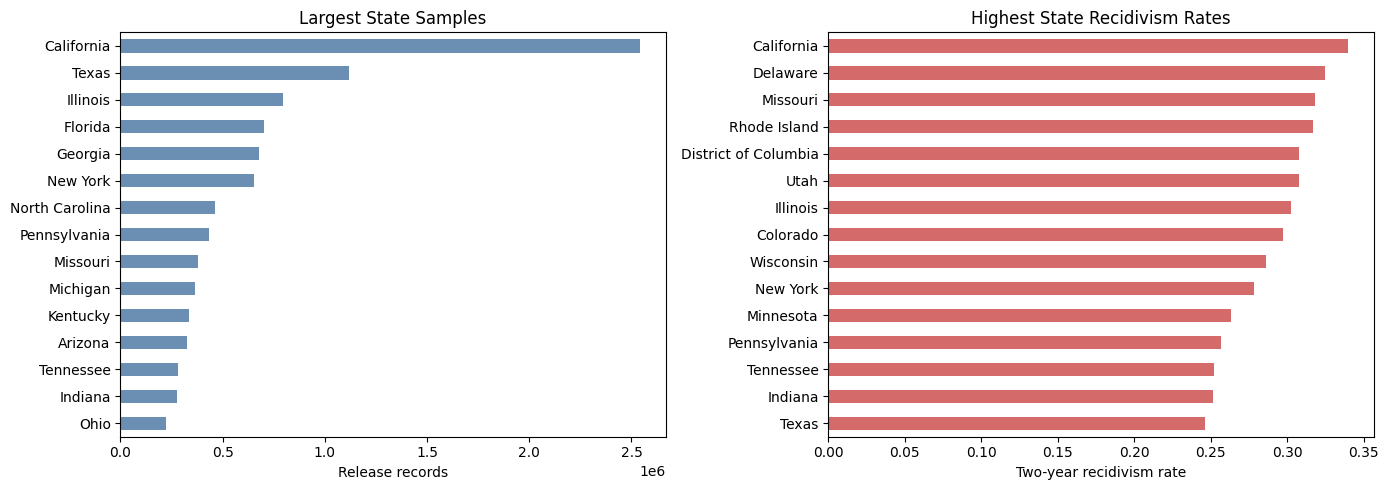

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

state_summary.head(15)["releases"].sort_values().plot(
    kind="barh", ax=axes[0], color="#6b8fb3"
)
axes[0].set_title("Largest State Samples")
axes[0].set_xlabel("Release records")
axes[0].set_ylabel("")

state_summary.sort_values("recid_rate").tail(15)["recid_rate"].plot(
    kind="barh", ax=axes[1], color="#d46a6a"
)
axes[1].set_title("Highest State Recidivism Rates")
axes[1].set_xlabel("Two-year recidivism rate")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 6. Recidivism Outcome

Inspect the dependent variable before modeling. The project defines recidivism as return to prison within two years of release.

A zero or near-zero rate in the final release year is a censoring warning, not a substantive finding. Releases near the end of the panel may not have enough future observation time to identify returns.

In [8]:
outcome_counts = (
    df["within_2_yrs"]
    .value_counts(dropna=False)
    .rename_axis("within_2_yrs")
    .to_frame("records")
)
outcome_counts["share"] = outcome_counts["records"] / outcome_counts["records"].sum()
outcome_counts

,records,share
within_2_yrs,,
0,8515409,0.737
1,3032576,0.263


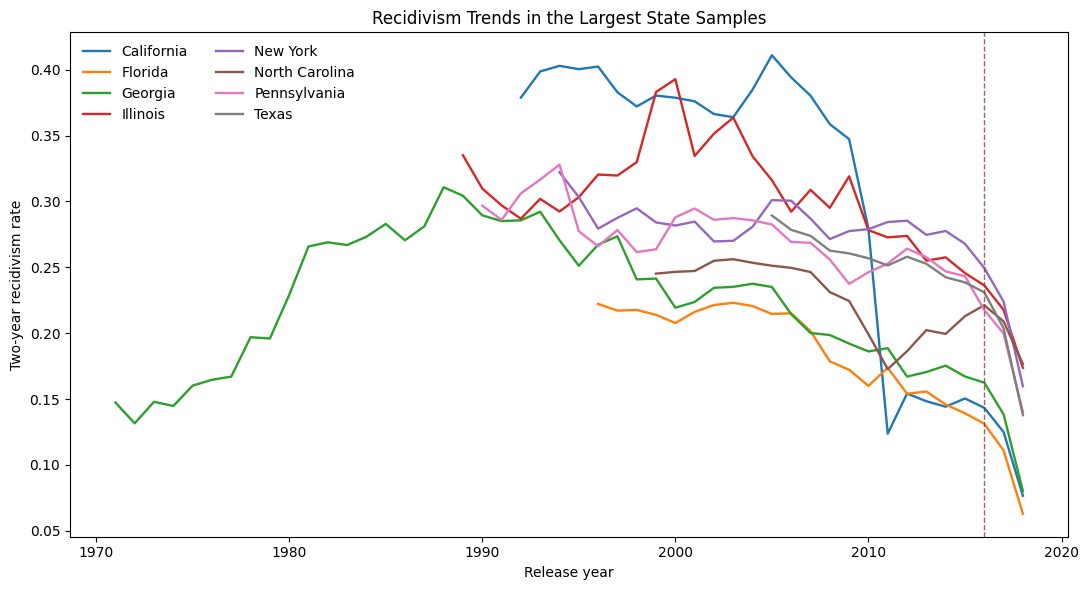

In [9]:
state_year = (
    df.groupby(["STATE_NAME", "RELEASEYR"], observed=True)["within_2_yrs"]
    .agg(recid_rate="mean", releases="size")
    .reset_index()
)

large_states = state_summary.head(8).index.tolist()
plot_df = state_year[state_year["STATE_NAME"].isin(large_states)]

fig, ax = plt.subplots(figsize=(11, 6))
for state, temp in plot_df.groupby("STATE_NAME", observed=True):
    ax.plot(temp["RELEASEYR"], temp["recid_rate"], linewidth=1.7, label=state)

ax.axvline(2016, color="#8a3d3d", linestyle="--", linewidth=1, alpha=0.8)
ax.set_title("Recidivism Trends in the Largest State Samples")
ax.set_xlabel("Release year")
ax.set_ylabel("Two-year recidivism rate")
ax.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

## 7. Individual Composition

Describe demographics, offense categories, sentence length, and prior incarceration history. These variables become controls or sample restrictions in the regression notebooks.

In [10]:
sex_labels = {1: "Male", 2: "Female", 9: "Missing"}
age_labels = {1: "18-24", 2: "25-34", 3: "35-44", 4: "45-54", 5: "55+", 9: "Missing"}
race_labels = {
    1: "White, non-Hispanic",
    2: "Black, non-Hispanic",
    3: "Hispanic",
    4: "Other race, non-Hispanic",
    9: "Missing",
}
offense_labels = {
    1: "Violent",
    2: "Property",
    3: "Drug",
    4: "Public order",
    5: "Other",
    9: "Missing",
}


def labeled_distribution(frame, col, labels=None):
    out = (
        frame[col]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis(col)
        .to_frame("records")
    )
    out["share"] = out["records"] / out["records"].sum()
    if labels is not None:
        out["label"] = out.index.map(labels)
    return out


labeled_distribution(df, "SEX", sex_labels)

,records,share,label
SEX,,,
1,10273676,0.890,Male
2,1274309,0.110,Female


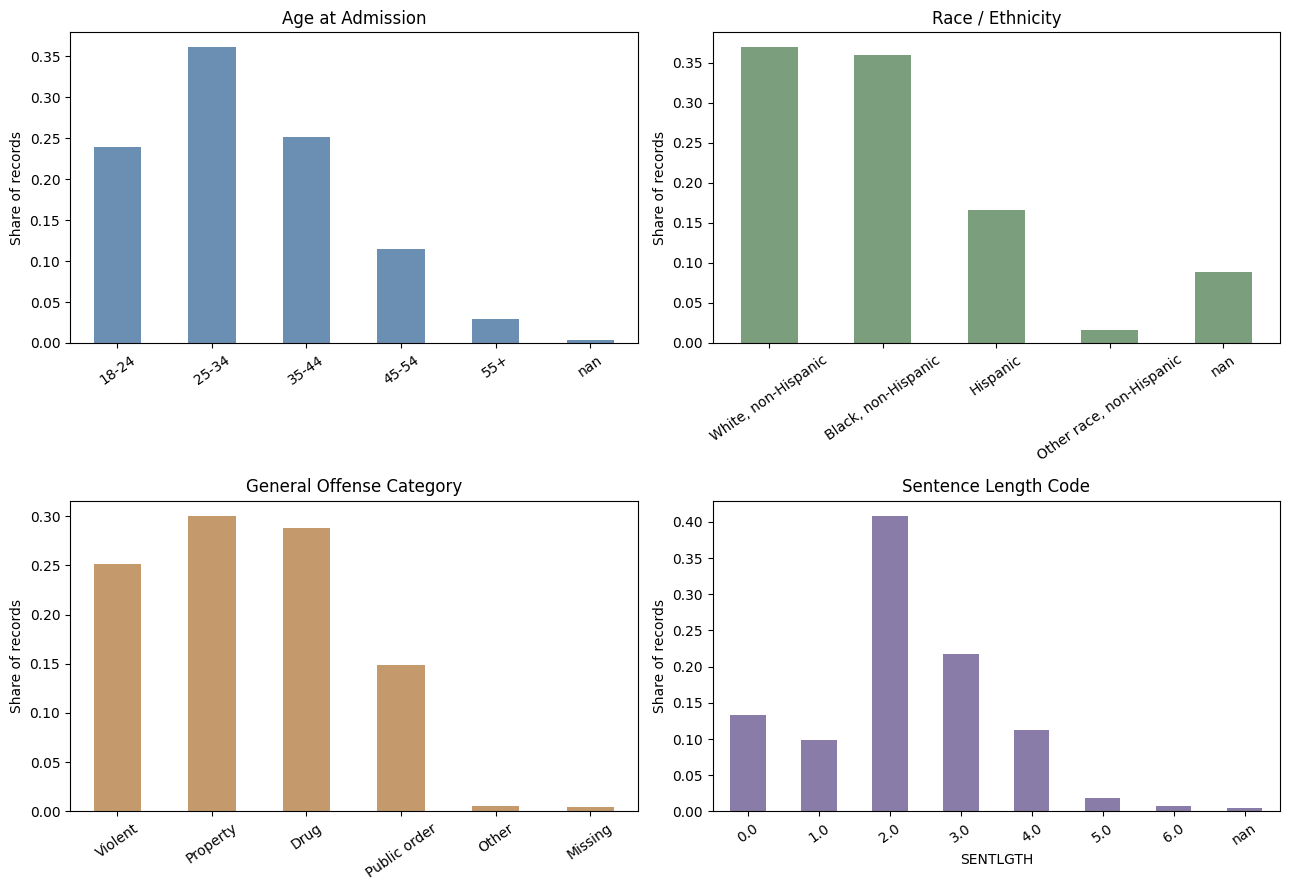

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

labeled_distribution(df, "AGEADMIT", age_labels).set_index("label")["share"].plot(
    kind="bar", ax=axes[0, 0], color="#6b8fb3"
)
axes[0, 0].set_title("Age at Admission")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Share of records")

labeled_distribution(df, "RACE", race_labels).set_index("label")["share"].plot(
    kind="bar", ax=axes[0, 1], color="#7b9e7d"
)
axes[0, 1].set_title("Race / Ethnicity")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Share of records")

labeled_distribution(df, "OFFGENERAL", offense_labels).set_index("label")["share"].plot(
    kind="bar", ax=axes[1, 0], color="#c49a6c"
)
axes[1, 0].set_title("General Offense Category")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Share of records")

labeled_distribution(df, "SENTLGTH")["share"].plot(
    kind="bar", ax=axes[1, 1], color="#8a7ca8"
)
axes[1, 1].set_title("Sentence Length Code")
axes[1, 1].set_xlabel("SENTLGTH")
axes[1, 1].set_ylabel("Share of records")

for ax in axes.ravel():
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

In [12]:
control_summary = (
    df.groupby("OFFGENERAL", observed=True)
    .agg(records=("within_2_yrs", "size"), recid_rate=("within_2_yrs", "mean"))
    .rename(index=offense_labels)
)
control_summary["share"] = control_summary["records"] / control_summary["records"].sum()
control_summary.sort_values("recid_rate", ascending=False)

,records,recid_rate,share
OFFGENERAL,,,
Property,3471340,0.302,0.301
Drug,3326776,0.262,0.288
Public order,1723554,0.238,0.149
Violent,2902215,0.232,0.251
Other,68880,0.228,0.006
Missing,55220,0.210,0.005


## 8. Repeat Incarceration History

`tot_arrest_counts` counts how many records each inmate has in the cleaned sample. Because this value is repeated on every row for the same person, person-level summaries should first collapse to one row per inmate.

In [13]:
person_records = df.drop_duplicates("ABT_INMATE_ID")["tot_arrest_counts"]
person_records.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count   6143985.000
mean          1.880
std           1.601
min           1.000
50%           1.000
75%           2.000
90%           4.000
95%           5.000
99%           8.000
max          30.000
Name: tot_arrest_counts, dtype: Float64

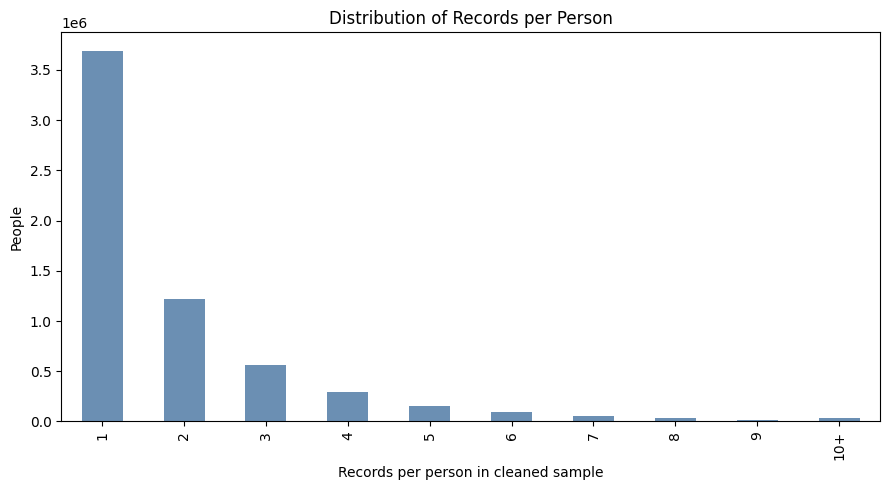

tot_arrest_counts
1      3689794
2      1215119
3       559110
4       289925
5       158156
6        90017
7        52265
8        31886
9        19337
10+      38376
Name: count, dtype: Int64

In [14]:
person_repeat_dist = person_records.clip(upper=10).value_counts().sort_index()
person_repeat_dist.index = person_repeat_dist.index.astype(str)
person_repeat_dist = person_repeat_dist.rename(index={"10": "10+"})

fig, ax = plt.subplots(figsize=(9, 5))
person_repeat_dist.plot(kind="bar", ax=ax, color="#6b8fb3")
ax.set_title("Distribution of Records per Person")
ax.set_xlabel("Records per person in cleaned sample")
ax.set_ylabel("People")
plt.tight_layout()
plt.show()

person_repeat_dist

## 9. Policy Context

These are descriptive comparisons only. Policy variables are attached at the state level, so raw differences reflect state composition, time period, offense mix, and sample size — not causal policy effects.

Note: the raw policy tier comparison (High > Low recidivism) appears counterintuitive. This is a composition artifact: California dominates the High tier with 2.5M records and a 33.9% recidivism rate — the highest of any state — pulling the group average up. The regression notebooks isolate policy associations after controlling for state and year fixed effects.

In [15]:
policy_missing_states = sorted(
    df.loc[df["Total_Score"].isna(), "STATE_NAME"].dropna().astype(str).unique()
)
print(f"States with missing policy data: {policy_missing_states}")

policy_cols = [
    "ABE_Literacy",
    "Secondary",
    "Vocational",
    "College",
    "Automatic_Enrollment",
    "School_District",
    "Sentence_Reduction",
    "Total_Score",
]

policy_state = (
    df[["STATE_NAME"] + policy_cols]
    .drop_duplicates()
    .sort_values("Total_Score", ascending=False)
)
policy_state.head(15)

States with missing policy data: ['District of Columbia']


,STATE_NAME,ABE_Literacy,Secondary,Vocational,College,Automatic_Enrollment,School_District,Sentence_Reduction,Total_Score
8638488,Ohio,1.000,1.000,0.500,1.000,1.000,1.000,1.000,6.500
478741,California,0.750,0.750,0.750,1.000,1.000,1.000,1.000,6.250
5749891,Iowa,1.000,1.000,1.000,0.750,1.000,0.000,1.000,5.750
9461523,Rhode Island,1.000,1.000,1.000,0.500,0.000,1.000,1.000,5.500
4680217,Illinois,0.750,0.250,0.500,0.750,1.000,1.000,1.000,5.250
8619374,North Dakota,1.000,1.000,1.000,1.000,0.000,0.000,1.000,5.000
7501671,New York,0.750,0.500,0.750,1.000,0.000,1.000,1.000,5.000
7315395,New Jersey,0.500,1.000,0.750,0.500,1.000,0.000,1.000,4.750
10007347,Texas,0.500,0.500,0.250,0.250,1.000,1.000,1.000,4.500
9514713,South Carolina,1.000,0.000,0.500,0.000,1.000,1.000,1.000,4.500


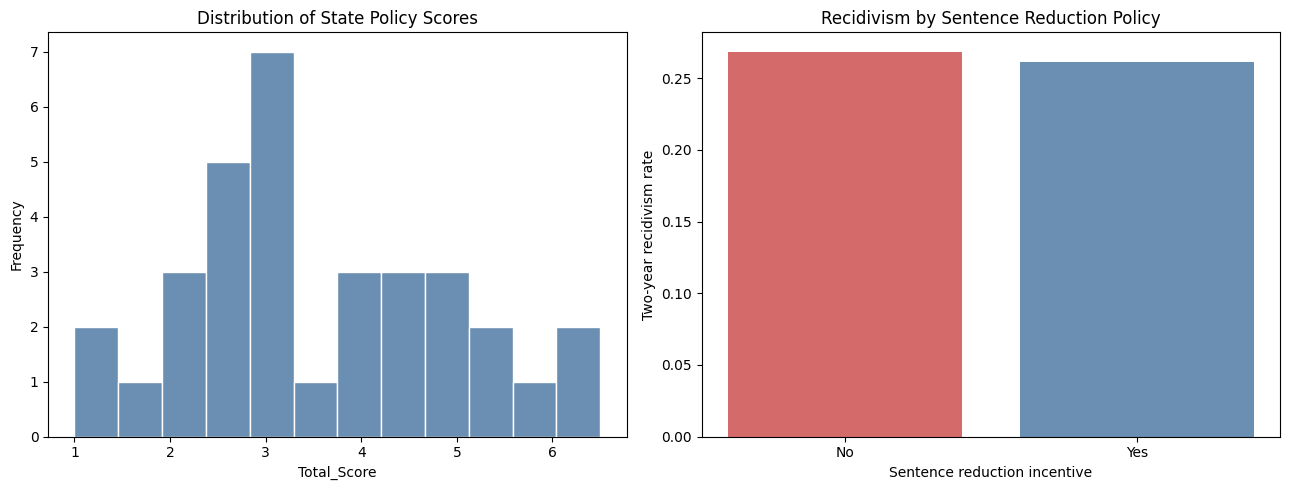

,Sentence_Reduction,recid_rate,records
0,No,0.269,1495049
1,Yes,0.262,10007819


In [16]:
policy_rates = (
    df.groupby("Sentence_Reduction", observed=True)["within_2_yrs"]
    .agg(recid_rate="mean", records="size")
    .reset_index()
)
policy_rates["Sentence_Reduction"] = policy_rates["Sentence_Reduction"].map(
    {0.0: "No", 1.0: "Yes"}
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

policy_state["Total_Score"].plot(
    kind="hist", bins=12, ax=axes[0], color="#6b8fb3", edgecolor="white"
)
axes[0].set_title("Distribution of State Policy Scores")
axes[0].set_xlabel("Total_Score")

axes[1].bar(
    policy_rates["Sentence_Reduction"],
    policy_rates["recid_rate"],
    color=["#d46a6a", "#6b8fb3"],
)
axes[1].set_title("Recidivism by Sentence Reduction Policy")
axes[1].set_xlabel("Sentence reduction incentive")
axes[1].set_ylabel("Two-year recidivism rate")

plt.tight_layout()
plt.show()

policy_rates

In [17]:
if "policy_tier" in df.columns:
    tier_summary = df.groupby("policy_tier", observed=True).agg(
        records=("within_2_yrs", "size"),
        states=("STATE_NAME", "nunique"),
        recid_rate=("within_2_yrs", "mean"),
    )
    display(tier_summary)
else:
    print("policy_tier is not present in this version of the cleaned file.")

,records,states,recid_rate
policy_tier,,,
High,3685137,5,0.320
Low,4042482,14,0.225
Medium,3775249,14,0.246


## 10. EDA Takeaways

Summarize what the descriptive analysis implies for the modeling notebooks. These takeaways are generated from the current data so they stay aligned with the executed outputs.

In [ ]:
analysis_df = df[(df["RELEASEYR"] >= 2005) & (df["RELEASEYR"] <= 2017)]
latest_year = df["RELEASEYR"].max()
latest_rate = df.loc[df["RELEASEYR"] == latest_year, "within_2_yrs"].mean()
policy_missing_states = sorted(
    df.loc[df["Total_Score"].isna(), "STATE_NAME"].dropna().astype(str).unique()
)

takeaways = [
    f"The cleaned file contains {len(df):,} release records across {df['STATE_NAME'].nunique()} states from {df['RELEASEYR'].min()} to {df['RELEASEYR'].max()}.",
    f"For the modern 2005-2017 window, the sample contains {len(analysis_df):,} records with a recidivism rate of {analysis_df['within_2_yrs'].mean():.1%}.",
    f"The final release year ({latest_year}) has a recidivism rate of {latest_rate:.1%}, which should be treated as a censoring warning rather than a substantive result.",
    f"Policy variables are missing for {len(policy_missing_states)} retained state{'s' if len(policy_missing_states) != 1 else ''}: {policy_missing_states}.",
    "State, year, offense, age, sex, and sentence-length differences are large enough that raw descriptive comparisons should not be interpreted causally.",
]

for i, item in enumerate(takeaways, start=1):
    print(f"{i}. {item}")